In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score

In [10]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
data=pd.read_csv('/content/creditcard.csv')
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [8]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [12]:
data.shape

(284807, 31)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [14]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [16]:
data=data.drop_duplicates()

In [17]:
data.duplicated().sum()

np.int64(0)

In [18]:
data['Class'].value_counts()

,count
Class,
0,283253
1,473


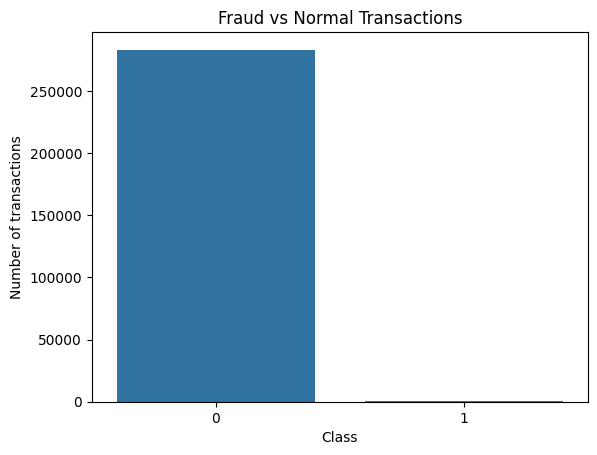

In [19]:
sns.countplot(x='Class',data=data)
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class')
plt.ylabel('Number of transactions')
plt.show()

In [20]:
fraud_percentage=data['Class'].value_counts(normalize=True)*100
print(fraud_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


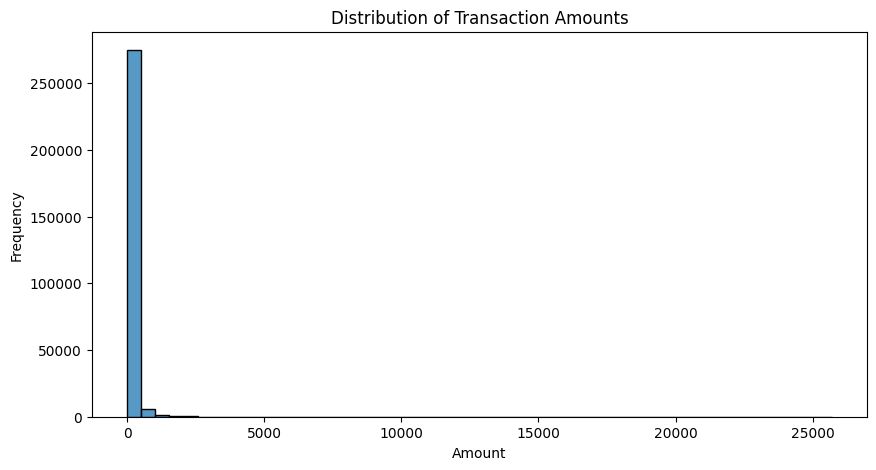

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(data['Amount'],bins=50)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

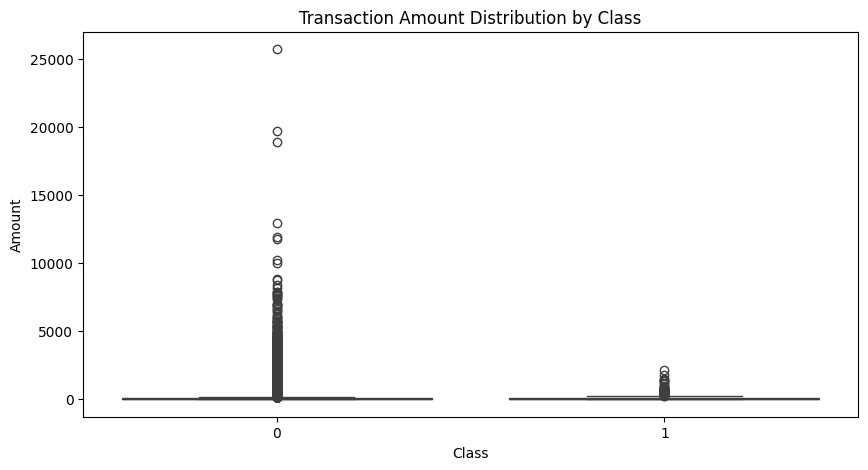

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Class',y='Amount',data=data)
plt.title('Transaction Amount Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Amount')
plt.show()

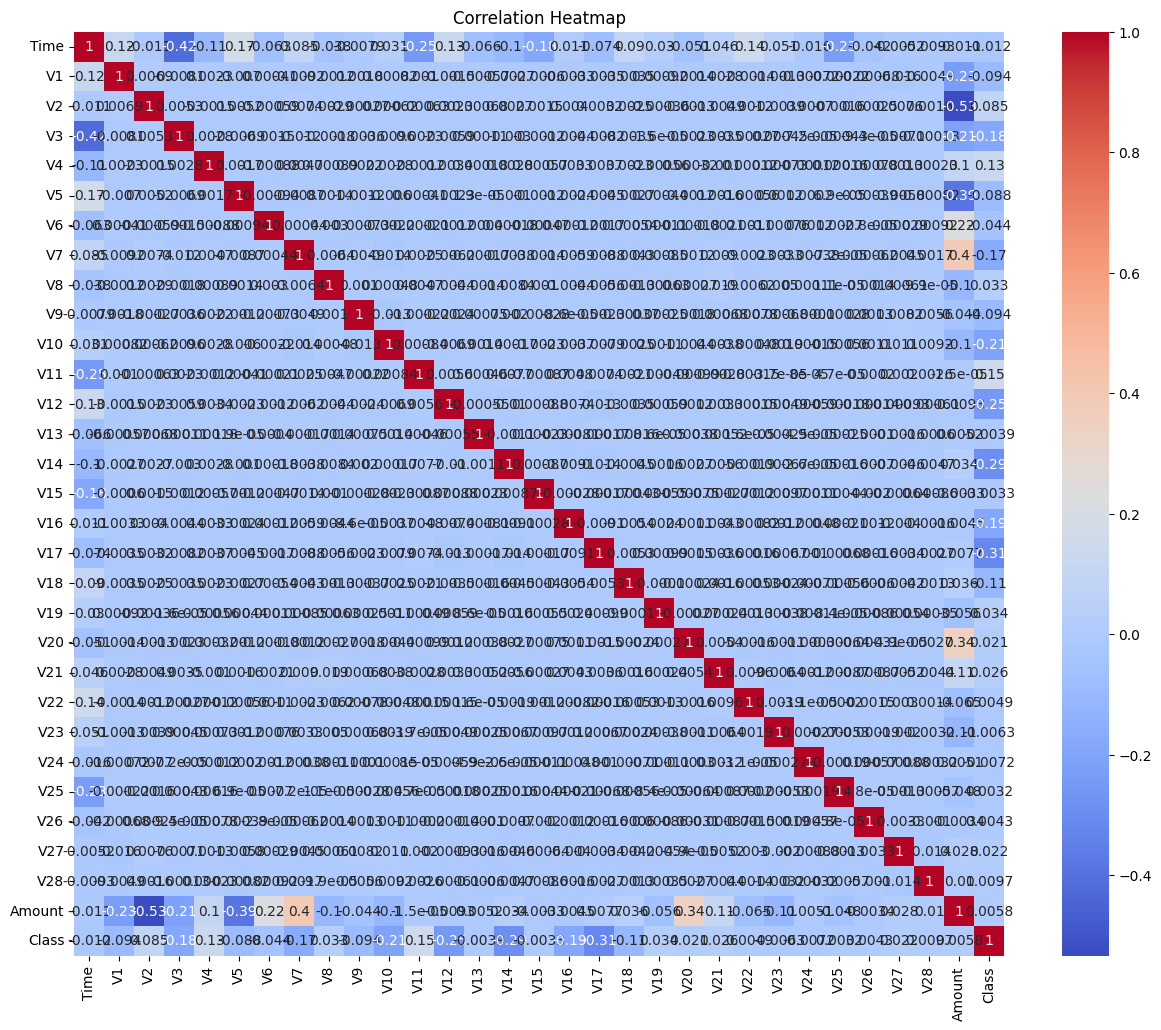

In [27]:
plt.figure(figsize=(15,12))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
X=data.drop('Class',axis=1)
y=data['Class']

In [29]:
scaler=StandardScaler()
X['Amount']=scaler.fit_transform(X[['Amount']])

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [58]:
smote=SMOTE(random_state=42,sampling_strategy=0.2)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [59]:
print('Before SMOTE:')
print(y_train.value_counts())
print('After SMOTE:')
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE:
Class
0    226602
1     45320
Name: count, dtype: int64


In [60]:
lr=LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train_smote,y_train_smote)

LogisticRegression(max_iter=1000, solver='liblinear')

In [61]:
y_pred_lr=lr.predict(X_test)

In [62]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.9962111866915729
Precision: 0.2744360902255639
Recall: 0.7684210526315789
F1 Score: 0.40443213296398894


In [63]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.27      0.77      0.40        95

    accuracy                           1.00     56746
   macro avg       0.64      0.88      0.70     56746
weighted avg       1.00      1.00      1.00     56746



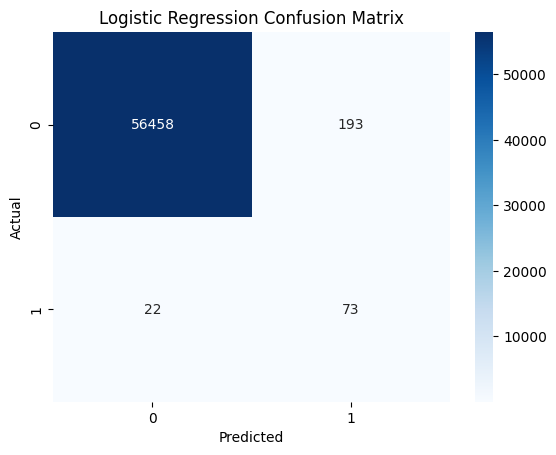

In [64]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [66]:
rf = RandomForestClassifier(n_estimators=30,max_depth=10,class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=30,
                       n_jobs=-1, random_state=42)

In [67]:
y_pred_rf = rf.predict(X_test)

In [68]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9994008388256441
Precision: 0.8860759493670886
Recall: 0.7368421052631579
F1 Score: 0.8045977011494253


In [69]:
xgb = XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42,eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [70]:
y_pred_xgb = xgb.predict(X_test)

In [71]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.9992422373383146
Precision: 0.7653061224489796
Recall: 0.7894736842105263
F1 Score: 0.7772020725388601


In [72]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.996211,0.274436,0.768421,0.404432
1,Random Forest,0.999401,0.886076,0.736842,0.804598
2,XGBoost,0.999242,0.765306,0.789474,0.777202


In [73]:
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False)
importance.head(10)

,0
V14,0.275121
V17,0.112346
V3,0.110748
V10,0.093942
V4,0.073922
V12,0.065028
V16,0.047188
V27,0.023915
V2,0.020272
V9,0.018621


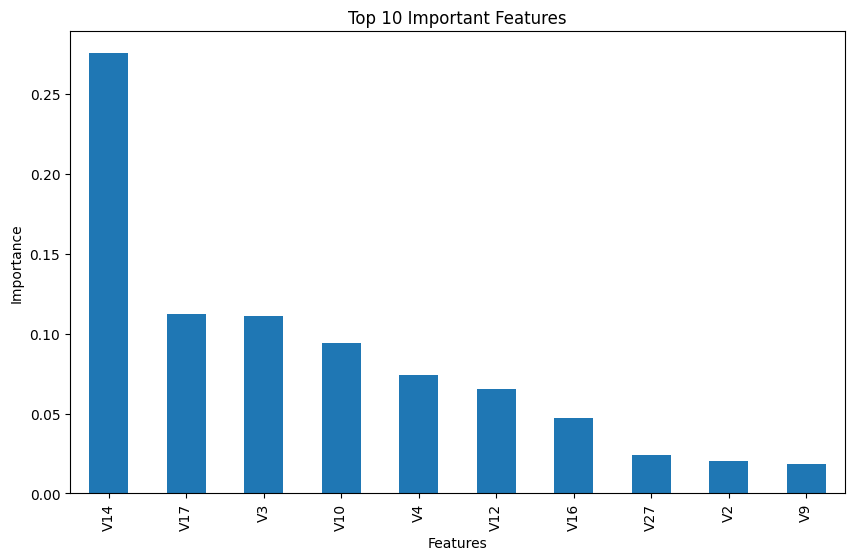

In [74]:
plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [75]:
lr_prob = lr.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]
print("Logistic Regression ROC-AUC:",roc_auc_score(y_test, lr_prob))
print("Random Forest ROC-AUC:",roc_auc_score(y_test, rf_prob))
print("XGBoost ROC-AUC:",roc_auc_score(y_test, xgb_prob))

Logistic Regression ROC-AUC: 0.9219486997488779
Random Forest ROC-AUC: 0.944502953912645
XGBoost ROC-AUC: 0.968422910730428


In [76]:
transaction = X_test.iloc[0:1]
prediction = xgb.predict(transaction)
probability = xgb.predict_proba(transaction)[0][1]
print("Fraud Probability:", probability)
if prediction[0] == 1:
    print("⚠️ FRAUDULENT TRANSACTION")
else:
    print("✅ NORMAL TRANSACTION")

Fraud Probability: 0.00037279437
✅ NORMAL TRANSACTION


In [77]:
import joblib
joblib.dump(xgb, 'fraud_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## Conclusion

A machine learning based fraud detection system was developed
using Logistic Regression, Random Forest and XGBoost.

The dataset was highly imbalanced, so SMOTE was applied to the
training data to improve the model's ability to identify fraudulent
transactions.

The models were evaluated using accuracy, precision, recall,
F1-score and ROC-AUC.

Since fraud detection prioritizes identifying fraudulent
transactions, recall and F1-score were given greater importance
than accuracy alone.